# KIT4 Data

This notebook is created by Claude Sonnet 4.6 with a customized agent.

This notebook inspects the pre-loaded KIT4 MATLAB data files used by the D-bar reconstruction pipeline. It focuses on:

- loading the shipped `.mat` files,
- checking variable names, dtypes, and shapes,
- plotting the mesh,
- visualizing each dataset according to its role in the pipeline,
- and running basic cross-file consistency checks.

The notebook uses experiment `3`, version `5` by default, matching the standalone Python example.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from scipy.io import loadmat

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "viridis"

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
KIT4_DIR = ROOT / "KIT4_measdata"
EXAMPLE = 3
VERSION = 5
MEAS_PATH = KIT4_DIR / f"dataMat_adj_{EXAMPLE}_{VERSION}.mat"

FILE_MAP = {
    "mesh": DATA_DIR / "mesh.mat",
    "elec": DATA_DIR / "elecMeas_adj.mat",
    "ang": DATA_DIR / "angPars_adj.mat",
    "theta": DATA_DIR / "theta.mat",
    "psi": DATA_DIR / "psi_BIE.mat",
    "dn": DATA_DIR / "DN.mat",
    "nd": DATA_DIR / "ND.mat",
    "kvec": DATA_DIR / "ex2Kvec.mat",
    "tbie": DATA_DIR / "ex2tBIE.mat",
    "recon": DATA_DIR / "reconstruction.mat",
    "meas": MEAS_PATH,
}


def load_clean_mat(path: Path) -> dict[str, np.ndarray]:
    raw = loadmat(path)
    return {key: value for key, value in raw.items() if not key.startswith("__")}


def describe_array(value: np.ndarray) -> dict[str, object]:
    arr = np.asarray(value)
    return {
        "shape": arr.shape,
        "dtype": str(arr.dtype),
        "min": float(np.nanmin(np.real(arr))) if arr.size else np.nan,
        "max": float(np.nanmax(np.real(arr))) if arr.size else np.nan,
    }


def print_summary(name: str, data: dict[str, np.ndarray]) -> None:
    print(f"{name}: {FILE_MAP[name].name}")
    for key, value in data.items():
        info = describe_array(value)
        print(
            f"  {key:12s} shape={info['shape']!s:14s} dtype={info['dtype']:>10s} "
            f"real-range=[{info['min']:.4g}, {info['max']:.4g}]"
        )
    print()


loaded = {name: load_clean_mat(path) for name, path in FILE_MAP.items()}
for name, data in loaded.items():
    print_summary(name, data)

mesh: mesh.mat
  dgm          shape=(12, 4)        dtype=     int16 real-range=[-1, 1]
  p            shape=(2, 8321)      dtype=   float64 real-range=[-1, 1]
  e            shape=(7, 256)       dtype=   float64 real-range=[0, 2241]
  t            shape=(4, 16384)     dtype=    uint16 real-range=[1, 8321]
  ecenters     shape=(2, 256)       dtype=   float64 real-range=[-0.9998, 0.9998]
  bfii         shape=(1, 256)       dtype=   float64 real-range=[-3.129, 3.129]
  btri_ind     shape=(1, 256)       dtype=    uint16 real-range=[1, 1.086e+04]
  elengths     shape=(1, 256)       dtype=   float64 real-range=[0.02454, 0.02454]
  Nbound       shape=(1, 1)         dtype=    uint16 real-range=[256, 256]

elec: elecMeas_adj.mat
  L            shape=(1, 1)         dtype=     uint8 real-range=[16, 16]
  Nvec         shape=(1, 16)        dtype=     uint8 real-range=[1, 16]
  Ntrig        shape=(1, 15)        dtype=     uint8 real-range=[1, 8]
  U_tr         shape=(16, 16)       dtype=   float64 r

## Mesh

The mesh is stored as node coordinates `p` and triangle connectivity `t`, following MATLAB conventions. The code below converts triangle indices from 1-based to 0-based indexing, verifies that the connectivity stays inside the node range, and plots the finite-element triangulation.

p shape: (2, 8321)
t shape: (4, 16384)
triangle index range: 0 8320
number of nodes: 8321
number of triangles: 16384


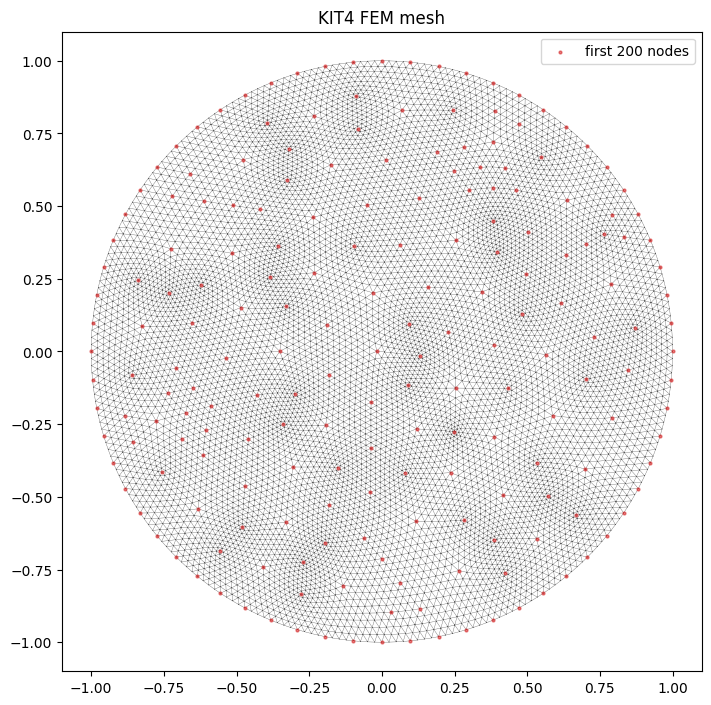

In [3]:
mesh = loaded["mesh"]
p = np.asarray(mesh["p"], dtype=np.float64)
t = np.asarray(mesh["t"])
triangles = np.asarray(t[:3, :].T - 1, dtype=np.int32)

print("p shape:", p.shape)
print("t shape:", t.shape)
print("triangle index range:", int(triangles.min()), int(triangles.max()))
print("number of nodes:", p.shape[1])
print("number of triangles:", triangles.shape[0])

if p.shape[0] != 2:
    raise ValueError(f"Expected p to have shape (2, n_nodes), got {p.shape}.")
if triangles.min() < 0 or triangles.max() >= p.shape[1]:
    raise ValueError("Triangle connectivity is out of bounds after 1-based to 0-based conversion.")

triang = mtri.Triangulation(p[0, :], p[1, :], triangles)
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.triplot(triang, color="0.35", linewidth=0.25)
ax.scatter(p[0, :200], p[1, :200], s=4, color="tab:red", alpha=0.6, label="first 200 nodes")
ax.set_title("KIT4 FEM mesh")
ax.set_aspect("equal")
ax.legend(loc="upper right")
plt.show()

##  Electrode Measurement Metadata

`elecMeas_adj.mat` contains metadata for the adjacent-drive acquisition and the trig basis used later in the pipeline. A stem plot is appropriate for `Ntrig` because it is an ordered list of mode indices rather than a continuous signal.

L: 16
Nvec: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Ntrig shape: (15,)
Ntrig values: [1 2 3 4 5 6 7 8 7 6 5 4 3 2 1]
U_tr shape: (16, 16)
U_1 shape: (16, 16)


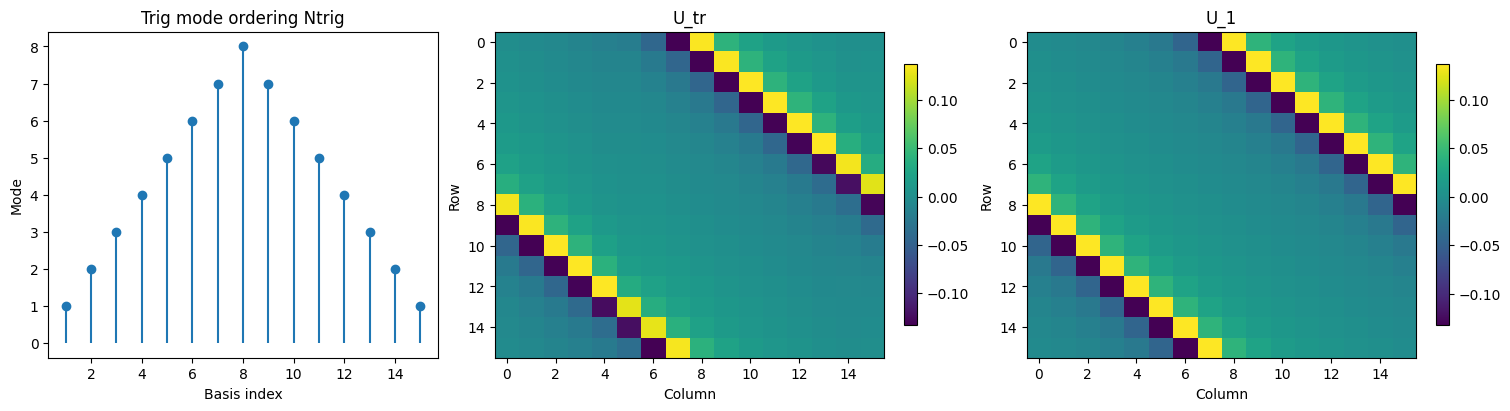

In [4]:
elec = loaded["elec"]
L = int(np.asarray(elec["L"]).squeeze())
Nvec = np.asarray(elec["Nvec"]).ravel().astype(int)
Ntrig = np.asarray(elec["Ntrig"]).ravel().astype(int)
U_tr = np.asarray(elec["U_tr"], dtype=np.float64)
U_1 = np.asarray(elec["U_1"], dtype=np.float64)

print("L:", L)
print("Nvec:", Nvec)
print("Ntrig shape:", Ntrig.shape)
print("Ntrig values:", Ntrig)
print("U_tr shape:", U_tr.shape)
print("U_1 shape:", U_1.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].stem(np.arange(1, Ntrig.size + 1), Ntrig, basefmt=" ")
axes[0].set_title("Trig mode ordering Ntrig")
axes[0].set_xlabel("Basis index")
axes[0].set_ylabel("Mode")

im1 = axes[1].imshow(U_tr, aspect="auto")
axes[1].set_title("U_tr")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(U_1, aspect="auto")
axes[2].set_title("U_1")
axes[2].set_xlabel("Column")
axes[2].set_ylabel("Row")
fig.colorbar(im2, ax=axes[2], shrink=0.8)
plt.show()

## Angular Parameter Data

`angPars_adj.mat` provides the angular sampling used for boundary traces. The code checks whether the stored spacing `Dfii` matches the observed successive differences in `fii`.

`fii`: the angular grid tied to the measured boundary traces and the ND-map construction.

In [ ]:
ang = loaded["ang"]
fii = np.asarray(ang["fii"], dtype=np.float64).ravel()
Dfii = float(np.asarray(ang["Dfii"]).squeeze())
ang_ind = np.asarray(ang["ind"]).ravel()
# order in which boundary sample positions are arranged relative to the angular grid fii. The first Nvec[0] entries correspond to the first electrode, the next Nvec[1] entries to the second electrode, and so on.
fii_diff = np.diff(fii)

print("fii shape:", fii.shape)
print("Dfii:", Dfii)
print("ind shape:", ang_ind.shape)

print(fii[:10])
print(ang_ind[:10])

fii shape: (256,)
Dfii: 0.024543692606170175
ind shape: (256,)
[3.14159265 3.16613635 3.19068004 3.21522373 3.23976742 3.26431112
 3.28885481 3.3133985  3.33794219 3.36248589]
[  1 129  65 193  33 161  97 225   2 130]


## Boundary Sampling Data

`theta.mat` stores the angular boundary quadrature grid used later in the scattering-transform stage. The plots below confirm that the grid is regular and consistent with the stored scalar `Dtheta`.


`theta`: the uniform boundary quadrature grid used in the BIE stage on the model boundary, boundary points are $e^{i\theta_k}$.

In [ ]:
theta_data = loaded["theta"]
theta = np.asarray(theta_data["theta"], dtype=np.float64).ravel()
# theta is just np.linspace(0, 2 * np.pi, Ntheta, endpoint=False)
Dtheta = float(np.asarray(theta_data["Dtheta"]).squeeze())
Ntheta = int(np.asarray(theta_data["Ntheta"]).squeeze())
theta_diff = np.diff(theta)

print("theta shape:", theta.shape)
print("Ntheta:", Ntheta)
print("Dtheta:", Dtheta)



theta shape: (256,)
Ntheta: 256
Dtheta: 0.02454369260617026


## Precomputed psi_BIE Data

`Fpsi_BIE` is a complex matrix of precomputed boundary-integral quantities indexed by trig basis and scattering-grid point. Real-part, imaginary-part, and magnitude heatmaps are the most direct way to check its structure.

Fpsi_BIE shape: (15, 3852)
Fpsi_BIE dtype: complex128
psi mode indices: [1 2 3 4 5 6 7 8 7 6 5 4 3 2 1]
|Fpsi_BIE| min/max: 8.201342208314201e-05 1391266.7257487385


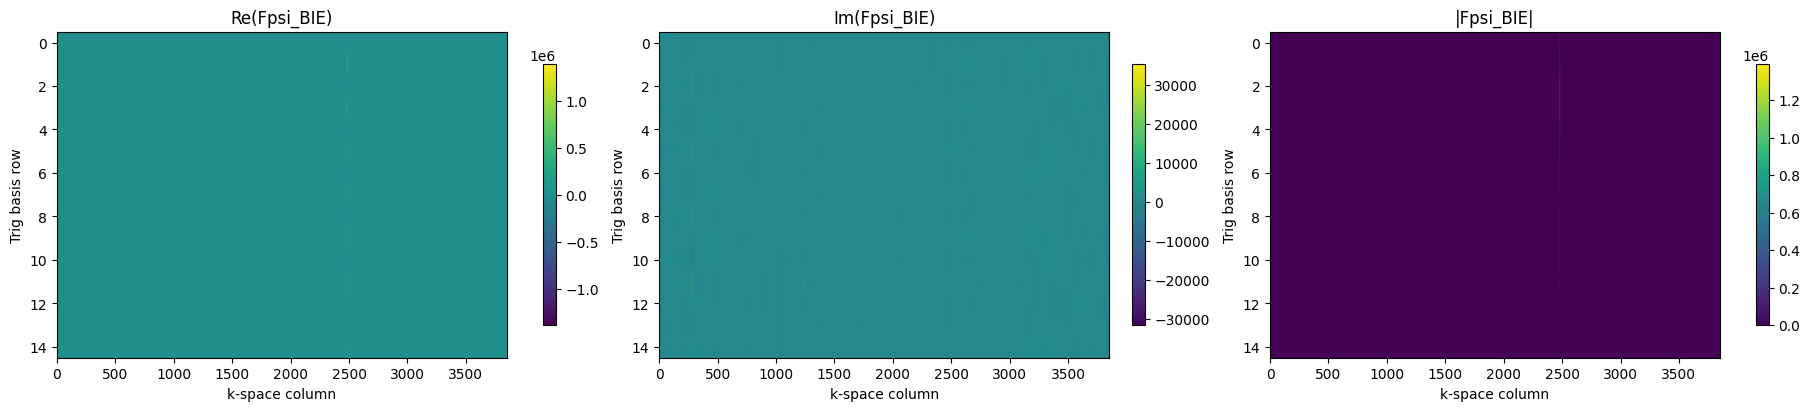

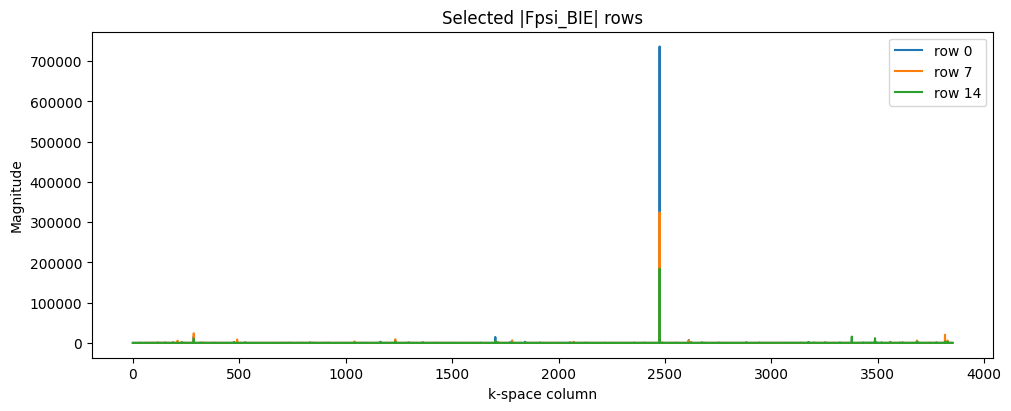

In [6]:
psi = loaded["psi"]
Fpsi_BIE = np.asarray(psi["Fpsi_BIE"], dtype=np.complex128)
psi_modes = np.asarray(psi["Nvec"]).ravel().astype(int)

print("Fpsi_BIE shape:", Fpsi_BIE.shape)
print("Fpsi_BIE dtype:", Fpsi_BIE.dtype)
print("psi mode indices:", psi_modes)
print("|Fpsi_BIE| min/max:", float(np.abs(Fpsi_BIE).min()), float(np.abs(Fpsi_BIE).max()))

fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
plots = [np.real(Fpsi_BIE), np.imag(Fpsi_BIE), np.abs(Fpsi_BIE)]
titles = ["Re(Fpsi_BIE)", "Im(Fpsi_BIE)", "|Fpsi_BIE|"]
for ax, values, title in zip(axes, plots, titles):
    im = ax.imshow(values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("k-space column")
    ax.set_ylabel("Trig basis row")
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
for row_idx in [0, Fpsi_BIE.shape[0] // 2, Fpsi_BIE.shape[0] - 1]:
    ax.plot(np.abs(Fpsi_BIE[row_idx]), label=f"row {row_idx}")
ax.set_title("Selected |Fpsi_BIE| rows")
ax.set_xlabel("k-space column")
ax.set_ylabel("Magnitude")
ax.legend()
plt.show()

## KIT4 Measurement Matrices

The selected KIT4 MAT file contains the adjacent-drive voltage matrices `U_ad0` and `U_ad10`. Since these are square measurement operators, side-by-side heatmaps and their difference are the most useful first diagnostic.

1. Column j = the measured electrode voltages produced by adjacent current pattern j.
2. Row i = the voltage measured on electrode i for all drive patterns.
3. Before using them in the solver, the row order is rotated from 1..16 to 9..16, 1..8 to match the solver's boundary geometry in `comp02_ND_buildFromKIT4.m` line 25.
4. `U_ad0`:  target measurement matrix
5. `U_ad10` reference/background measurement matrix that becomes NtoD1 and then DN1.

measurement file: dataMat_adj_3_5.mat
MeasPat shape: (16, 16)
U_ad0 shape: (16, 16) min/max: -0.6941077265624999 0.6869853226562492
U_ad10 shape: (16, 16) min/max: -0.7013203875000001 0.6993669750000003
difference Frobenius norm: 0.3363035177075145


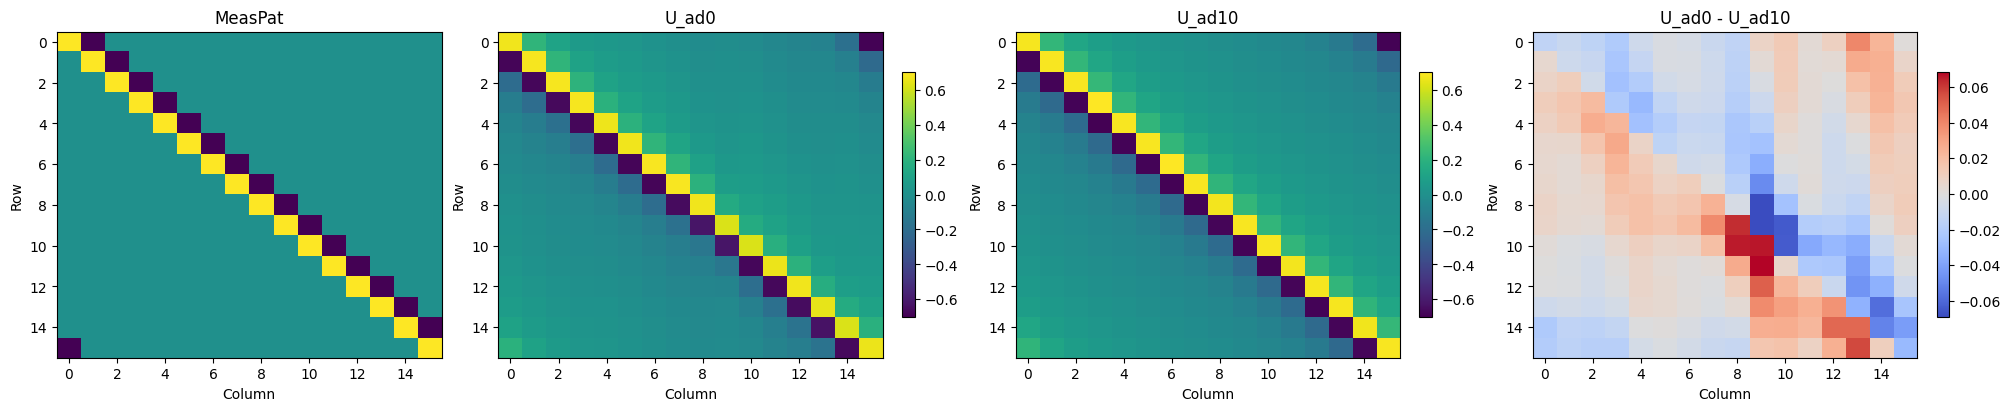

In [7]:
meas = loaded["meas"]
MeasPat = np.asarray(meas["MeasPat"])
U_ad0 = np.asarray(meas["U_ad0"], dtype=np.float64)
U_ad10 = np.asarray(meas["U_ad10"], dtype=np.float64)
U_diff = U_ad0 - U_ad10

print("measurement file:", MEAS_PATH.name)
print("MeasPat shape:", MeasPat.shape)
print("U_ad0 shape:", U_ad0.shape, "min/max:", float(U_ad0.min()), float(U_ad0.max()))
print("U_ad10 shape:", U_ad10.shape, "min/max:", float(U_ad10.min()), float(U_ad10.max()))
print("difference Frobenius norm:", float(np.linalg.norm(U_diff)))

shared_vmin = float(min(U_ad0.min(), U_ad10.min()))
shared_vmax = float(max(U_ad0.max(), U_ad10.max()))

fig, axes = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
axes[0].imshow(MeasPat, aspect="auto")
axes[0].set_title("MeasPat")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")

im1 = axes[1].imshow(U_ad0, aspect="auto", vmin=shared_vmin, vmax=shared_vmax)
axes[1].set_title("U_ad0")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

im2 = axes[2].imshow(U_ad10, aspect="auto", vmin=shared_vmin, vmax=shared_vmax)
axes[2].set_title("U_ad10")
axes[2].set_xlabel("Column")
axes[2].set_ylabel("Row")

im3 = axes[3].imshow(U_diff, aspect="auto", cmap="coolwarm")
axes[3].set_title("U_ad0 - U_ad10")
axes[3].set_xlabel("Column")
axes[3].set_ylabel("Row")

fig.colorbar(im1, ax=axes[1], shrink=0.75)
fig.colorbar(im2, ax=axes[2], shrink=0.75)
fig.colorbar(im3, ax=axes[3], shrink=0.75)
plt.show()

## Shape and Consistency Checks

These checks confirm the basic structural relationships assumed by the reconstruction code: matching trig-basis counts, square and same-sized measurement matrices, valid mesh connectivity, and agreement between the scattering-grid bookkeeping arrays.

In [8]:
kvec_data = loaded["kvec"]
tbie_data = loaded["tbie"]
recon_data = loaded["recon"]
dn_data = loaded["dn"]
nd_data = loaded["nd"]

checks = {
    "mesh p has two coordinate rows": p.shape[0] == 2,
    "triangle connectivity has three vertex rows": t.shape[0] >= 3,
    "triangle indices stay inside node range": triangles.min() >= 0 and triangles.max() < p.shape[1],
    "U_ad0 and U_ad10 share the same square shape": U_ad0.shape == U_ad10.shape and U_ad0.shape[0] == U_ad0.shape[1],
    "trig count matches Fpsi_BIE row count": Ntrig.size == Fpsi_BIE.shape[0],
    "theta sample count matches stored Ntheta": theta.size == Ntheta,
    "fii index array matches fii length": ang_ind.size == fii.size,
    "DN is square": np.asarray(dn_data["DN"]).shape[0] == np.asarray(dn_data["DN"]).shape[1],
    "ND is square": np.asarray(nd_data["NtoD"]).shape[0] == np.asarray(nd_data["NtoD"]).shape[1],
    "Kvec length matches tBIE length": np.asarray(kvec_data["Kvec"]).size == np.asarray(tbie_data["tBIE"]).size,
    "reference reconstruction length matches mesh nodes": np.asarray(recon_data["recon"]).size == p.shape[1],
}

for label, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {label}")

if not all(checks.values()):
    raise AssertionError("One or more KIT4 consistency checks failed.")

[PASS] mesh p has two coordinate rows
[PASS] triangle connectivity has three vertex rows
[PASS] triangle indices stay inside node range
[PASS] U_ad0 and U_ad10 share the same square shape
[PASS] trig count matches Fpsi_BIE row count
[PASS] theta sample count matches stored Ntheta
[PASS] fii index array matches fii length
[PASS] DN is square
[PASS] ND is square
[PASS] Kvec length matches tBIE length
[PASS] reference reconstruction length matches mesh nodes


## Precomputed Operators, Scattering Grid, and Reference Reconstruction

The repo also ships precomputed operator and reconstruction outputs. These are not required for the shape checks above, but they are useful sanity checks because they reflect later stages of the KIT4 pipeline:

- `DN.mat` and `ND.mat` store square operator matrices,
- `ex2Kvec.mat` and `ex2tBIE.mat` describe the scattering grid and scattering transform values,
- `reconstruction.mat` stores a reference conductivity image on the same mesh.

In [1]:
DN = np.asarray(dn_data["DN"], dtype=np.float64)
DN1 = np.asarray(dn_data["DN1"], dtype=np.float64)
NtoD = np.asarray(nd_data["NtoD"], dtype=np.float64)
NtoD1 = np.asarray(nd_data["NtoD1"], dtype=np.float64)
K1 = np.asarray(kvec_data["K1"], dtype=np.float64)
K2 = np.asarray(kvec_data["K2"], dtype=np.float64)
Kvec = np.asarray(kvec_data["Kvec"]).ravel().astype(np.complex128)
tBIE = np.asarray(tbie_data["tBIE"]).ravel().astype(np.complex128)
recon = np.asarray(recon_data["recon"], dtype=np.float64).ravel()


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].scatter(np.real(Kvec), np.imag(Kvec), s=5, alpha=0.5)
axes[0].set_title("Scattering grid points Kvec")
axes[0].set_xlabel("Re(k)")
axes[0].set_ylabel("Im(k)")
axes[0].set_aspect("equal")

scatter = axes[1].scatter(np.real(Kvec), np.imag(Kvec), c=np.abs(tBIE), s=7, cmap="magma")
axes[1].set_title("|tBIE| on Kvec")
axes[1].set_xlabel("Re(k)")
axes[1].set_ylabel("Im(k)")
axes[1].set_aspect("equal")
fig.colorbar(scatter, ax=axes[1], shrink=0.8)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].imshow(np.abs(K1 + 1j * K2) < float(np.asarray(kvec_data["tMAX"]).squeeze()), origin="lower")
axes[0].set_title("Disk mask |k| < tMAX on the K grid")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")

trip = axes[1].tripcolor(triang, recon, shading="flat")
axes[1].set_title("Reference reconstruction on the mesh")
axes[1].set_aspect("equal")
axes[1].axis("off")
fig.colorbar(trip, ax=axes[1], shrink=0.8)
plt.show()

NameError: name 'np' is not defined